<a href="https://colab.research.google.com/github/apirakqqqqq/GE337_Programming/blob/main/Lab_3/Lab_3_6606614870_%E0%B8%AD%E0%B8%A0%E0%B8%B4%E0%B8%A3%E0%B8%B1%E0%B8%81%E0%B8%A9%E0%B9%8C_%E0%B8%9B%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%AA%E0%B8%B2%E0%B8%84%E0%B8%A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install geopandas rasterio folium shapely matplotlib -q

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**โหลด Vector**

In [7]:
import geopandas as gpd

# พื้นที่ศึกษา
aoi = gpd.read_file('/content/แก่งกะจาน.json')

# จุด
point = gpd.read_file('/content/point_แก่งกะจาน.json')

print(aoi.head())
print(point.head())
print("CRS AOI:", aoi.crs)
print("CRS point:", point.crs)

   OBJECTID  OBJECTID_1 AMPHOE_IDN AMP_CODE      AMPHOE_T  \
0         1         843       7608       08  อ.แก่งกระจาน   

               AMPHOE_E PROV_CODE  PROV_NAM_T            PROV_NAM_E P_CODE  \
0  Amphoe Kaeng Krachan        76  จ.เพชรบุรี  Changwat Phetchaburi     PB   

   ORIG_FID     Shape_Leng   Shape_Length    Shape_Area  \
0       772  292395.157188  292395.157188  2.574200e+09   

                                            geometry  
0  POLYGON ((537294.379 1452309.376, 537429.692 1...  
Empty GeoDataFrame
Columns: [FID, AMPHOE_T, lat, long, Tambon, geometry]
Index: []
CRS AOI: EPSG:32647
CRS point: EPSG:32648


โหลด Raster Geotiff

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


raster_path_2024 = '/content/NDVI_2024_KaengKrachan.tif'
raster_path_2025 = '/content/NDVI_2025_KaengKrachan.tif'

src_2024 = rasterio.open(raster_path_2024)
print("===== NDVI 2024 =====")
print(src_2024.profile)

src_2025 = rasterio.open(raster_path_2025)
print("\n===== NDVI 2025 =====")
print(src_2025.profile)

===== NDVI 2024 =====
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 7744, 'height': 6666, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(8.983152841195215e-05, 0.0, 99.09854888292914,
       0.0, -8.983152841195215e-05, 13.139028840117357), 'blockxsize': 256, 'blockysize': 256, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}

===== NDVI 2025 =====
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 7744, 'height': 6666, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.017

**แสดงภาพ ndvi 2024 และ 2025**

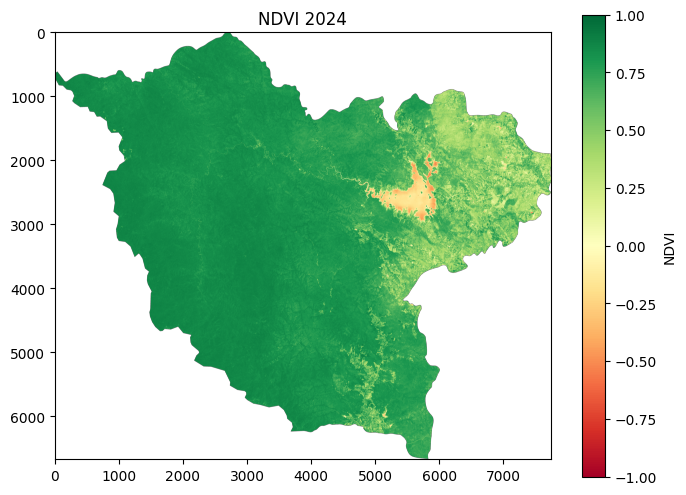

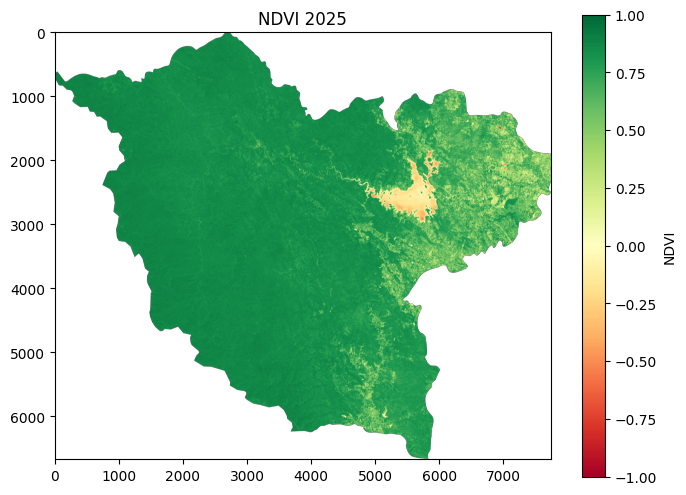

In [9]:

# ==============================
# โหลดไฟล์ NDVI ปี 2024
# ==============================
with rasterio.open('/content/NDVI_2024_KaengKrachan.tif') as src:
    ndvi_2024 = src.read(1)

# ==============================
# โหลดไฟล์ NDVI ปี 2025
# ==============================
with rasterio.open('/content/NDVI_2025_KaengKrachan.tif') as src:
    ndvi_2025 = src.read(1)

# ==============================
# แสดงผล NDVI ปี 2024
# ==============================
plt.figure(figsize=(8,6))
plt.imshow(ndvi_2024, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI 2024')
plt.show()

# ==============================
# แสดงผล NDVI ปี 2025
# ==============================
plt.figure(figsize=(8,6))
plt.imshow(ndvi_2025, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI')
plt.title('NDVI 2025')
plt.show()

**คำนวณ NDVI**

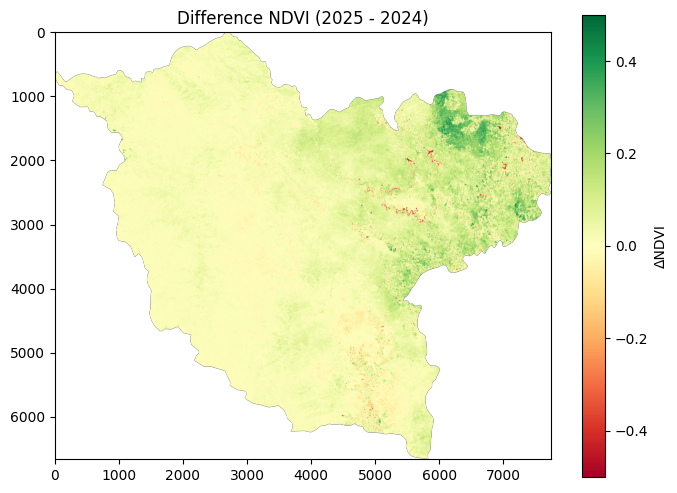

Export complete: /content/dNDVI_2025_2024_KaengKrachan.tif


In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# กำหนด path ไฟล์
# ==============================
ndvi_prev_path = '/content/NDVI_2024_KaengKrachan.tif'
ndvi_curr_path = '/content/NDVI_2025_KaengKrachan.tif'

# ปีเก่า
with rasterio.open(ndvi_prev_path) as src_prev:
    ndvi_prev = src_prev.read(1).astype('float32')
    profile = src_prev.profile   # เก็บ metadata ไว้ export

# ปีใหม่
with rasterio.open(ndvi_curr_path) as src_curr:
    ndvi_curr = src_curr.read(1).astype('float32')


# คำนวณ Difference NDVI

dNDVI = ndvi_curr - ndvi_prev

# แสดงผลลัพธ์

plt.figure(figsize=(8,6))
plt.imshow(dNDVI, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
plt.colorbar(label='ΔNDVI')
plt.title('Difference NDVI (2025 - 2024)')
plt.show()

# ==============================
# Export เป็น GeoTIFF
# ==============================

profile.update(
    dtype=rasterio.float32,
    count=1,

)

output_path = '/content/dNDVI_2025_2024_KaengKrachan.tif'

with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(dNDVI.astype('float32'), 1)

print("Export complete:", output_path)

**คำนวณ Difference NDVI**

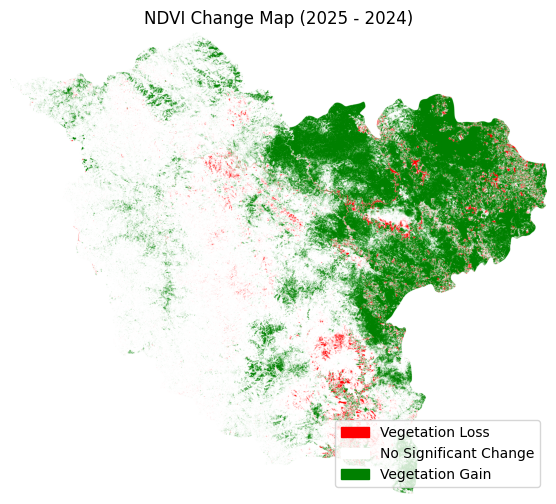

In [11]:
from matplotlib.colors import ListedColormap
# ==============================
# โหลดไฟล์ dNDVI
# ==============================
with rasterio.open('/content/dNDVI_2025_2024_KaengKrachan.tif') as src:
    dNDVI = src.read(1)

# ==============================
# กำหนด Threshold
# ==============================
threshold_loss = -0.05
threshold_gain = 0.05

change_map = np.zeros_like(dNDVI)

# -1 = vegetation loss
#  1 = vegetation gain
change_map[dNDVI < threshold_loss] = -1
change_map[dNDVI > threshold_gain] = 1

# ==============================
# สร้าง colormap
# ==============================
cmap = ListedColormap(['red', 'white', 'green'])

# ปรับค่าเพื่อให้แสดง 3 class
# -1 → 0 (แดง)
#  0 → 1 (ขาว)
#  1 → 2 (เขียว)
display_map = change_map + 1

# ==============================
# แสดงผลด้วย Matplotlib
# ==============================
plt.figure(figsize=(8,6))
plt.imshow(display_map, cmap=cmap)
plt.title('NDVI Change Map (2025 - 2024)')
plt.axis('off')

# ทำ legend แบบง่าย
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='Vegetation Loss')
white_patch = mpatches.Patch(color='white', label='No Significant Change')
green_patch = mpatches.Patch(color='green', label='Vegetation Gain')

plt.legend(handles=[red_patch, white_patch, green_patch],
           loc='lower right')

plt.show()

การวิเคราะห์ความสัมพันธ์ของ NDVI กับภูมิประเทศ

    Elevation  Mean_NDVI_2024  Mean_NDVI_2025
0           0        0.519778        0.577426
1         100        0.606183        0.694914
2         200        0.736693        0.783531
3         300        0.785869        0.818192
4         400        0.802473        0.828658
5         500        0.818803        0.838979
6         600        0.836276        0.849782
7         700        0.850232        0.858617
8         800        0.856681        0.861609
9         900        0.857156        0.860345
10       1000        0.856605        0.858662
11       1100        0.851600        0.853515
12       1200        0.837048        0.847943
13       1300        0.835953        0.844044
14       1400        0.848648        0.832734


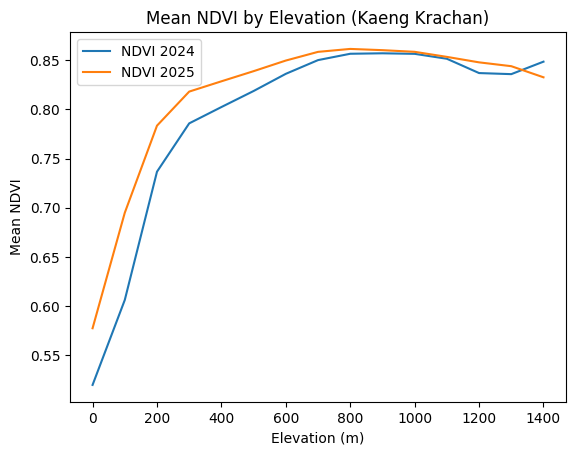

Correlation 2024: 0.7482454096954116
Correlation 2025: 0.6720638983579503


In [12]:
import pandas as pd
from rasterio.warp import reproject, Resampling
# ------------------------------------------
# 1) โหลด ROI
# ------------------------------------------
roi_gdf = gpd.read_file("/content/แก่งกะจาน.json")

# ------------------------------------------
# 2) โหลด DEM
# ------------------------------------------
dem_path = "/content/DEM_KaengKrachan.tif"
with rasterio.open(dem_path) as dem_src:
    dem = dem_src.read(1)
    dem_meta = dem_src.meta
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

# ------------------------------------------
# 3) โหลด NDVI 2024
# ------------------------------------------
ndvi2024_path = "/content/NDVI_2024_KaengKrachan.tif"
with rasterio.open(ndvi2024_path) as src:
    ndvi2024 = src.read(1)
    ndvi_transform = src.transform
    ndvi_crs = src.crs

# ------------------------------------------
# 4) โหลด NDVI 2025
# ------------------------------------------
ndvi2025_path = "/content/NDVI_2025_KaengKrachan.tif"
with rasterio.open(ndvi2025_path) as src:
    ndvi2025 = src.read(1)

# ------------------------------------------
# 5) Resample DEM ให้ตรงกับ NDVI
# ------------------------------------------
dem_resampled = np.empty_like(ndvi2024)

reproject(
    source=dem,
    destination=dem_resampled,
    src_transform=dem_transform,
    src_crs=dem_crs,
    dst_transform=ndvi_transform,
    dst_crs=ndvi_crs,
    resampling=Resampling.bilinear
)

# ------------------------------------------
# 6) คำนวณ Mean NDVI ตามช่วง Elevation
# ------------------------------------------
bins = np.arange(0, 1500, 100)

results_2024 = []
results_2025 = []

for b in bins:
    mask = (dem_resampled >= b) & (dem_resampled < b+100)

    if np.any(mask):
        mean24 = np.nanmean(ndvi2024[mask])
        mean25 = np.nanmean(ndvi2025[mask])

        results_2024.append([b, mean24])
        results_2025.append([b, mean25])

df24 = pd.DataFrame(results_2024, columns=["Elevation", "Mean_NDVI_2024"])
df25 = pd.DataFrame(results_2025, columns=["Elevation", "Mean_NDVI_2025"])

df = df24.merge(df25, on="Elevation")

print(df)

# ------------------------------------------
# 7) Plot แนวโน้ม
# ------------------------------------------
plt.figure()
plt.plot(df["Elevation"], df["Mean_NDVI_2024"], label="NDVI 2024")
plt.plot(df["Elevation"], df["Mean_NDVI_2025"], label="NDVI 2025")
plt.xlabel("Elevation (m)")
plt.ylabel("Mean NDVI")
plt.title("Mean NDVI by Elevation (Kaeng Krachan)")
plt.legend()
plt.show()

# ------------------------------------------
# 8) Correlation
# ------------------------------------------
corr24 = df["Elevation"].corr(df["Mean_NDVI_2024"])
corr25 = df["Elevation"].corr(df["Mean_NDVI_2025"])

print("Correlation 2024:", corr24)
print("Correlation 2025:", corr25)

**ใช้ DEM เพื่อดูความสูงของพื้นที่มีผลหรือไม่**

- ความสูงมีผลต่อ NDVI อย่างชัดเจน
ยิ่งพื้นที่สูง ค่า NDVI ยิ่งเพิ่มขึ้น (จนถึงระดับหนึ่ง)

**คำนวณค่าเฉลี่ยของ NDVI ที่ระดับความสูงต่าง ๆ และวิเคราะห์แนวโน้ม**

- ผลการวิเคราะห์พบว่าความสูงมีความสัมพันธ์เชิงบวกกับค่า NDVI อย่างชัดเจน โดยค่า Correlation เท่ากับ 0.748 ในปี 2024 และ 0.672 ในปี 2025 แสดงให้เห็นว่าพื้นที่ที่มีระดับความสูงมากขึ้นมีแนวโน้มที่จะมีค่าความเขียวของพืชพรรณสูงขึ้น ทั้งนี้ค่า NDVI เพิ่มขึ้นอย่างต่อเนื่องตั้งแต่ระดับ 0–800 เมตร และสูงสุดในช่วงประมาณ 800–1000 เมตร ก่อนจะเริ่มทรงตัวหรือลดลงเล็กน้อยในระดับความสูงมากกว่า 1000 เมตร ซึ่งอาจเกิดจากข้อจำกัดทางภูมิประเทศและสภาพภูมิอากาศบนพื้นที่สูง

็แสดงภาพ Histogram การเปลี่ยนแปลงของ NDVI

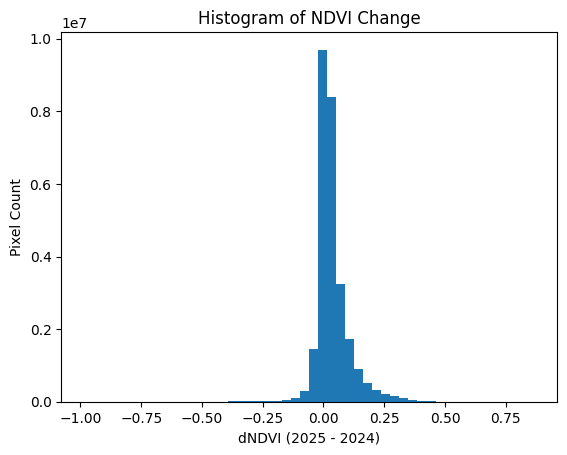

Mean Change: 0.0371021
Std Dev: 0.067723416
Increase Area (%): 77.52665701646785
Decrease Area (%): 22.472066740837455
Stable Area (%): 0.001276242694699051


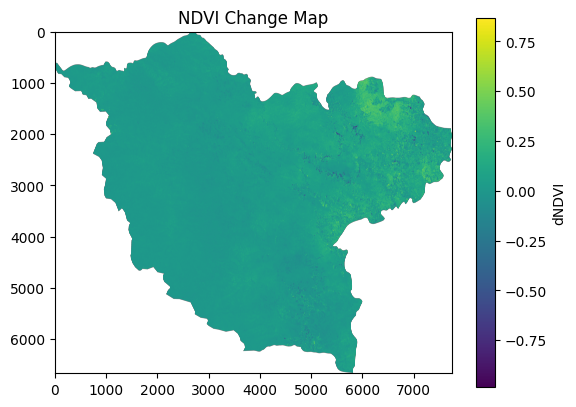

In [13]:

# ------------------------------------------
# 1) โหลด NDVI 2024
# ------------------------------------------
with rasterio.open("/content/NDVI_2024_KaengKrachan.tif") as src:
    ndvi2024 = src.read(1)
    meta = src.meta

# ------------------------------------------
# 2) โหลด NDVI 2025
# ------------------------------------------
with rasterio.open("/content/NDVI_2025_KaengKrachan.tif") as src:
    ndvi2025 = src.read(1)

# ------------------------------------------
# 3) โหลด dNDVI (2025 - 2024)
# ------------------------------------------
with rasterio.open("/content/dNDVI_2025_2024_KaengKrachan.tif") as src:
    dndvi = src.read(1)

# ทำความสะอาดค่า
dndvi = np.where(np.isfinite(dndvi), dndvi, np.nan)

# ------------------------------------------
# 4) Histogram การเปลี่ยนแปลง NDVI
# ------------------------------------------
plt.figure()
plt.hist(dndvi.flatten(), bins=50)
plt.xlabel("dNDVI (2025 - 2024)")
plt.ylabel("Pixel Count")
plt.title("Histogram of NDVI Change")
plt.show()

# ------------------------------------------
# 5) คำนวณสถิติ
# ------------------------------------------
mean_change = np.nanmean(dndvi)
std_change = np.nanstd(dndvi)

increase = np.sum(dndvi > 0)
decrease = np.sum(dndvi < 0)
stable = np.sum(dndvi == 0)

total = np.sum(~np.isnan(dndvi))

print("Mean Change:", mean_change)
print("Std Dev:", std_change)
print("Increase Area (%):", (increase/total)*100)
print("Decrease Area (%):", (decrease/total)*100)
print("Stable Area (%):", (stable/total)*100)

# ------------------------------------------
# 6) จำแนกระดับการเปลี่ยนแปลง
# ------------------------------------------
classification = np.zeros_like(dndvi)

classification[(dndvi >= 0.2)] = 2      # เพิ่มมาก
classification[(dndvi > 0) & (dndvi < 0.2)] = 1   # เพิ่มเล็กน้อย
classification[(dndvi < 0) & (dndvi > -0.2)] = -1 # ลดเล็กน้อย
classification[(dndvi <= -0.2)] = -2    # ลดมาก

# ------------------------------------------
# 7) แสดงแผนที่ dNDVI
# ------------------------------------------
plt.figure()
plt.imshow(dndvi)
plt.colorbar(label="dNDVI")
plt.title("NDVI Change Map")
plt.show()

**พื้นที่เพิ่ม/ลด**

- ในส่วนที่เพิ่มขึ้น พื้นที่ส่วนใหญ่ของอุทยานเป็นสีเขียวฟ้าอ่อน (ค่าบวกเล็กน้อย) โดยเฉพาะบริเวณตอนกลางและบางส่วนของด้านตะวันออก
พื้นที่: พื้นที่ป่าธรรมชาติ, โซนภูเขาระดับกลาง–สูง, พื้นที่ที่ไม่ถูกรบกวน
- ในส่วนที่ลด ขอบพื้นที่ บางส่วนด้านล่างของภาพ (พื้นที่ต่ำ), บริเวณใกล้ชุมชน/พื้นที่ราบ
ลักษณะนี้อาจเกี่ยวข้องกับ: พื้นที่เกษตร, พื้นที่บุกรุก, พื้นที่ได้รับผลกระทบจากไฟป่าเฉพาะจุด, พื้นที่ริมน้ำที่ระดับน้ำเปลี่ยน

**ปัจจัยที่ส่งผลกระทบ**

- ปัจจัยที่มีแนวโน้มส่งผลต่อ NDVI มากที่สุดคือความแตกต่างของฤดูกาล โดยเฉพาะปริมาณฝนและความชื้นที่แตกต่างกันระหว่างสองปี นอกจากนี้สภาพภูมิอากาศ เช่น อุณหภูมิและภาวะแห้งแล้ง ก็อาจมีส่วนทำให้ค่า NDVI เปลี่ยนแปลงได้ อีกทั้งระดับความสูงของพื้นที่ก็มีผลชัดเจน เนื่องจากพื้นที่สูงมีแนวโน้มค่าความเขียวมากกว่าพื้นที่ราบ ส่วนการใช้ที่ดินอาจมีผลเฉพาะบางจุด แต่ไม่พบการเปลี่ยนแปลงรุนแรงในวงกว้าง


**คำถามท้าย Lab**

**1. ทำไมการวิเคราะห์ NDVI จากภาพถ่ายดาวเทียมหลายช่วงเวลาจึงมีความสำคัญ?**

**2. พื้นที่ที่มีการเปลี่ยนแปลง NDVI อย่างมีนัยสำคัญควรได้รับการตรวจสอบเพิ่มเติมอย่างไร?**

**3. ปัจจัยใดที่อาจทำให้ค่า NDVI เปลี่ยนแปลงโดยไม่เกี่ยวข้องกับการเปลี่ยนแปลงของพืชพรรณ?**

**4. หากต้องการเพิ่มความแม่นยำของการวิเคราะห์การเปลี่ยนแปลง NDVI ควรใช้เทคนิคอะไรเพิ่มเติม?**

**5. ทำไมการใช้ DEM จึงช่วยให้เข้าใจบริบทของ NDVI ได้ดีขึ้น?**